In [2]:
!mkdir names

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import string, unicodedata, glob, os, time, random
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_default_device(device)
print(f"Using device = {device}")

Using device = cuda


In [4]:
allowed_characters = string.ascii_letters + " ,'" + "_"
n_letters = len(allowed_characters)

def unicodeToAscii(s):
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'
        and c in allowed_characters
    )

def letterToIndex(letter):
    if letter not in allowed_characters:
        return allowed_characters.find("_")
    return allowed_characters.find(letter)

def lineToTensor(line):
    tensor = torch.zeros(len(line), 1, n_letters)
    for li, letter in enumerate(line):
        tensor[li][0][letterToIndex(letter)] = 1
    return tensor

print(f"Vocabulary size: {n_letters}")
print(f"'Ślusàrski' → '{unicodeToAscii('Ślusàrski')}'")

Vocabulary size: 56
'Ślusàrski' → 'Slusarski'


In [5]:
from io import open
from torch.utils.data import Dataset

class NamesDataset(Dataset):
    def __init__(self, data_dir):
        self.data_dir = data_dir
        self.load_time = time.localtime
        labels_set = set()

        self.data, self.data_tensors = [], []
        self.labels, self.labels_tensors = [], []

        text_files = glob.glob(os.path.join(data_dir, '*.txt'))
        for filename in text_files:
            label = os.path.splitext(os.path.basename(filename))[0]
            labels_set.add(label)
            lines = open(filename, encoding='utf-8').read().strip().split('\n')
            for name in lines:
                self.data.append(name)
                self.data_tensors.append(lineToTensor(unicodeToAscii(name)))
                self.labels.append(label)

        self.labels_uniq = list(labels_set)
        for idx in range(len(self.labels)):
            temp = torch.tensor([self.labels_uniq.index(self.labels[idx])], dtype=torch.long)
            self.labels_tensors.append(temp)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return (self.labels_tensors[idx], self.data_tensors[idx],
                self.labels[idx], self.data[idx])

alldata = NamesDataset('names')
print(f"Total samples : {len(alldata)}")
print(f"Classes ({len(alldata.labels_uniq)}): {sorted(alldata.labels_uniq)}")

Total samples : 10195
Classes (14): ['Arabic', 'Chinese', 'Czech', 'Dutch', 'English', 'French', 'German', 'Greek', 'Irish', 'Italian', 'Japanese', 'Korean', 'Polish', 'Portuguese']


In [6]:
train_set, test_set = torch.utils.data.random_split(alldata, [.85, .15], generator=torch.Generator(device=device).manual_seed(2024))
print(f"Train: {len(train_set)} | Test: {len(test_set)}")

Train: 8666 | Test: 1529


In [7]:
class SimpleRNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers=1):
        super().__init__()
        self.input_size = input_size
        self.hidden_size =hidden_size
        self.num_layers  = num_layers

        # Each layer has its own (fc_ih, fc_hh)
        self.cells = nn.ModuleList()
        for i in range(num_layers):
            in_size = input_size if i == 0 else hidden_size
            self.cells.append(nn.ModuleDict({
                'ih': nn.Linear(in_size,    hidden_size),   # i - h
                'hh': nn.Linear(hidden_size, hidden_size),  # h - h
            }))

    def forward(self, x):
        T, B, _ = x.shape # x: (T, B, input_size)

        h = [torch.zeros(B, self.hidden_size, device=x.device) for _ in range(self.num_layers)]

        outputs = []
        for t in range(T):
            layer_input = x[t] # (B, input_size)
            for l, cell in enumerate(self.cells):
                h[l] = torch.tanh(cell['ih'](layer_input) + cell['hh'](h[l]))
                layer_input = h[l]
            outputs.append(h[-1])

        outputs     = torch.stack(outputs) # (T, B, hidden_size)
        last_hidden = torch.stack(h)
        return outputs, last_hidden

test = SimpleRNN(n_letters, 128, num_layers=2)
x = torch.zeros(6, 4, n_letters)
out, hid = test(x)

print(f"output shape : {out.shape}")
print(f"last_hidden shape : {hid.shape}")

output shape : torch.Size([6, 4, 128])
last_hidden shape : torch.Size([2, 4, 128])


In [8]:
class CharRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=1):
        super().__init__()
        self.rnn = SimpleRNN(input_size, hidden_size, num_layers=num_layers)
        self.h2o = nn.Linear(hidden_size, output_size)
        self.softmax = nn.LogSoftmax(dim=-1)

    def forward(self, line_tensor):
        # line_tensor: (T, B, C)
        out, hidden = self.rnn(line_tensor)
        last_h = hidden[-1] # (B, H)
        output = self.h2o(last_h) # (B, O)
        return self.softmax(output) # (B, O)

n_hidden = 128
n_classes = len(alldata.labels_uniq)
num_layers = 2

rnn = CharRNN(n_letters, n_hidden, n_classes, num_layers=num_layers)
print(rnn)

CharRNN(
  (rnn): SimpleRNN(
    (cells): ModuleList(
      (0): ModuleDict(
        (ih): Linear(in_features=56, out_features=128, bias=True)
        (hh): Linear(in_features=128, out_features=128, bias=True)
      )
      (1): ModuleDict(
        (ih): Linear(in_features=128, out_features=128, bias=True)
        (hh): Linear(in_features=128, out_features=128, bias=True)
      )
    )
  )
  (h2o): Linear(in_features=128, out_features=14, bias=True)
  (softmax): LogSoftmax(dim=-1)
)


In [9]:
from torch.utils.data import DataLoader

def collate_fn(batch):
    label_tensors = torch.cat([item[0] for item in batch])         # (B,)
    texts         = [item[1].squeeze(1) for item in batch] # (T, 1, C) = (T, C)
    data_labels   = [item[2] for item in batch]
    data_items    = [item[3] for item in batch]

    lengths = torch.tensor([t.shape[0] for t in texts])
    T_max   = lengths.max().item()
    C       = texts[0].shape[-1]
    B       = len(texts)

    padded = torch.zeros(T_max, B, C)
    for i, (t, l) in enumerate(zip(texts, lengths.tolist())):
        padded[:l, i, :] = t

    return label_tensors, padded, data_labels, data_items, lengths

batch_size = 32

train_loader = DataLoader(
    train_set, batch_size=batch_size, shuffle=True,
    collate_fn=collate_fn,
    generator=torch.Generator(device=device)
)
test_loader = DataLoader(
    test_set, batch_size=batch_size, shuffle=False,
    collate_fn=collate_fn,
    generator=torch.Generator(device=device)
)
print(f"Train batches: {len(train_loader)} | Test batches: {len(test_loader)}")


label_t, padded_t, _, _, lengths_t = next(iter(train_loader))
print(f"Batch label shape : {label_t.shape}")       # (32,)
print(f"Batch text shape  : {padded_t.shape}")      # (T_max, 32, 56)
print(f"Sequence lengths  : {lengths_t[:8].tolist()} ...")


Train batches: 271 | Test batches: 48
Batch label shape : torch.Size([32])
Batch text shape  : torch.Size([11, 32, 56])
Sequence lengths  : [6, 4, 9, 5, 6, 8, 7, 7] ...


In [10]:
criterion = nn.NLLLoss()
optimizer = torch.optim.AdamW(rnn.parameters(), lr=0.001)

all_losses = []
n_epochs   = 10

for epoch in range(1, n_epochs + 1):
    rnn.train()
    total_loss = 0.0

    for label_tensors, padded_text, _, _, lengths in train_loader:
        output = rnn(padded_text)  # (B, n_classes)
        loss   = criterion(output, label_tensors)   # NLLLoss

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(rnn.parameters(), 3)
        optimizer.step()

        total_loss += loss.item()

    epoch_loss = total_loss / len(train_loader)
    all_losses.append(epoch_loss)
    print(f"Epoch {epoch:02d}/{n_epochs} | loss = {epoch_loss:.4f}")

Epoch 01/10 | loss = 1.8492
Epoch 02/10 | loss = 1.5931
Epoch 03/10 | loss = 1.4898
Epoch 04/10 | loss = 1.4132
Epoch 05/10 | loss = 1.3092
Epoch 06/10 | loss = 1.2319
Epoch 07/10 | loss = 1.1243
Epoch 08/10 | loss = 1.0638
Epoch 09/10 | loss = 0.9936
Epoch 10/10 | loss = 0.9471


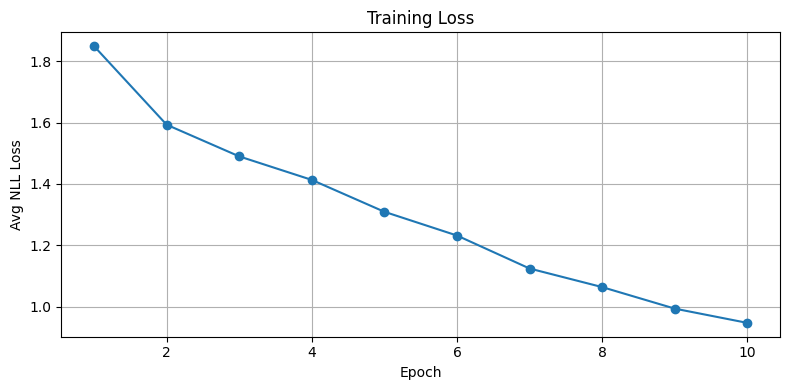

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(all_losses)+1), all_losses, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Avg NLL Loss")
plt.title("Training Loss")
plt.grid(True)
plt.tight_layout()
plt.show()

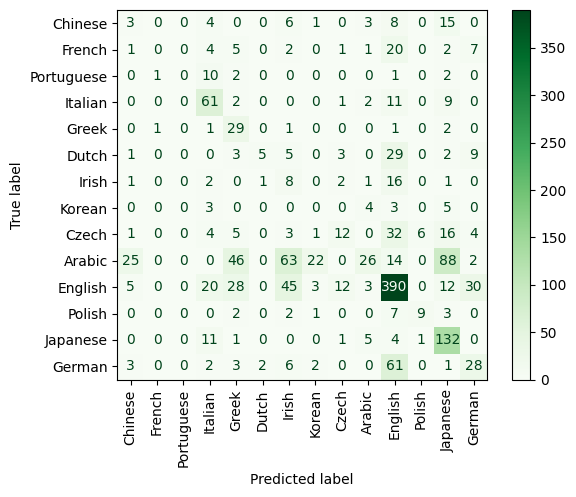

In [13]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

def evaluate(model, test_data, classes):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for label_tensor, text_tensor, label, _ in test_data:
            out  = model(text_tensor)
            pred = out.argmax(-1).item()
            y_true.append(classes.index(label))
            y_pred.append(pred)

    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=classes).plot(cmap="Greens", xticks_rotation=90)
    plt.show()

evaluate(rnn, test_set, classes=alldata.labels_uniq)

In [23]:
def predict(model, name, classes):
    model.eval()
    with torch.no_grad():
        tensor = lineToTensor(unicodeToAscii(name))     # (T, 1, C)
        output = model(tensor)                           # (1, n_classes)
        pred = output.argmax(-1).item()

        print(classes[pred])

In [24]:
predict(rnn, "george", alldata.labels_uniq)

English
